# MNIST

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.ensemble import IsolationForest
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

#from utils import seed_everything

In [2]:
import random
import numpy as np

def seed_everything(seed=42):
    """Fixes seeds to reproduce outcomes. Returns a NumPy random generator."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    # CUDA 10.2 or later
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    # PyTorch seeding
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    # CuDNN determinism (costs speed)
    # torch.use_deterministic_algorithms(True)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

    # numpy: create and return a generator instance
    rng = np.random.default_rng(seed)
    return rng


In [3]:
# --- CONSTANTS ---
RANDOM_SEED = 42

# --- SEEDING FUNCTIONALITY ---
rng = seed_everything(RANDOM_SEED)

# for num_workers > 0 in PyTorch DataLoader, each worker will inherit the exact same random state from the main process
# This means every worker will generate the exact same "random" data augmentations. We fix this using worker_init_fn
torch_gen = torch.Generator()
torch_gen.manual_seed(RANDOM_SEED)

In [4]:
mnist_train_raw = datasets.MNIST(
    root="./data",
    train=True,
    download=True, # download the data if it's not in ./data
)

mnist_test_raw = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
)

# Train/test sizes
print("\nTrain set: ")
print(mnist_train_raw.data.shape)

print("\nTest set: ")
print(mnist_test_raw.data.shape)


Train set: 
torch.Size([60000, 28, 28])

Test set: 
torch.Size([10000, 28, 28])


In [5]:
img, label = mnist_train_raw[0]

print(f"Image: {img}")
print(f"The label: {label}")

Image: <PIL.Image.Image image mode=L size=28x28 at 0x222630D6080>
The label: 5


Train images:


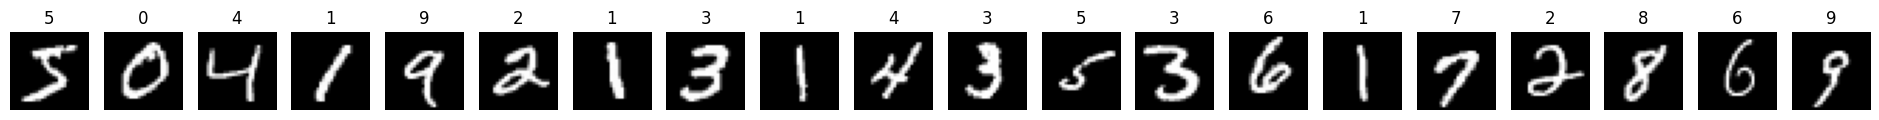

Test images:


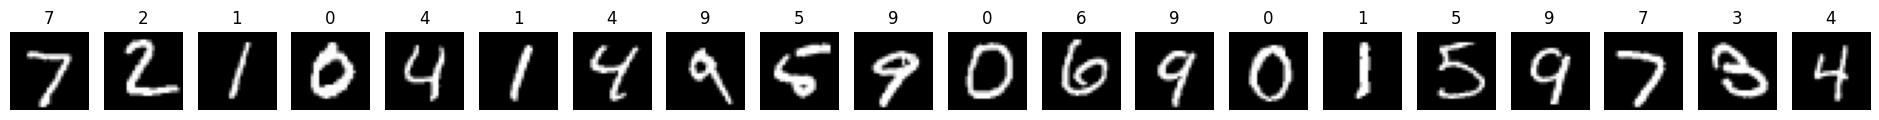

In [6]:
def plot_mnist_images(dataset, num_images: int):
    plt.figure(figsize=(24, 6))
    for i in range(num_images):
        img, label = dataset[i]
        if torch.is_tensor(img):
            img = img.squeeze()      # (1,28,28) -> (28,28)
        plt.subplot(
            1,              # a number of rows to plot on
            num_images,     # a number of columns
            i + 1,          # current position to plot in
        )
        plt.imshow(img, cmap='gray')
        plt.title(label)
        plt.axis('off')
    plt.show()

print("Train images:")
plot_mnist_images(mnist_train_raw, 20)

print("Test images:")
plot_mnist_images(mnist_test_raw, 20)

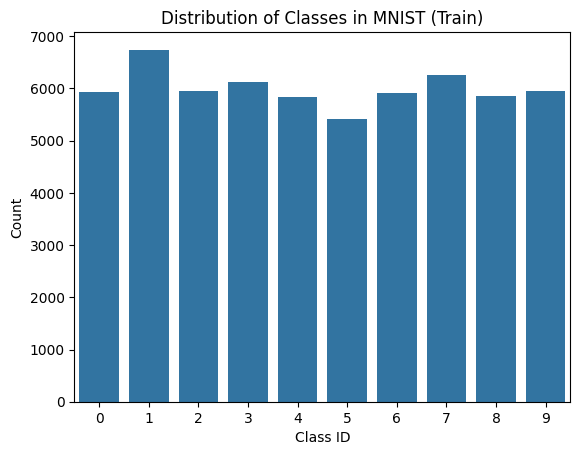

In [7]:
train_labels = mnist_train_raw.targets

sns.countplot(x=train_labels)
plt.title("Distribution of Classes in MNIST (Train)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

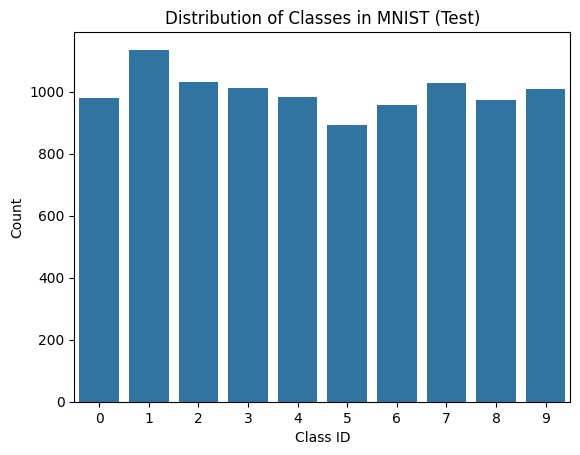

In [8]:
# to see if the classification report will be balanced
test_labels = mnist_test_raw.targets

sns.countplot(x=test_labels)
plt.title("Distribution of Classes in MNIST (Test)")
plt.xlabel("Class ID")
plt.ylabel("Count")
plt.show()

In [9]:
class MNISTDataset(Dataset):
    def __init__(self, data, targets, transform=None, transform_target=None):
        self.data = data
        self.targets = targets
        self.transform = transform
        self.transform_target = transform_target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], int(self.targets[idx])

        # MNIST dataset is already PIL
        # img = Image.fromarray(img.numpy(), mode="L")               # to PIL grayscale image
        if self.transform is not None:
            img = self.transform(img)

        if self.transform_target is not None:
            target = self.transform_target(target)
        return img, target

In [10]:
train_images = mnist_train_raw.data.numpy()
train_targets = mnist_train_raw.targets.numpy()

test_images = mnist_test_raw.data.numpy()
test_targets = mnist_test_raw.targets.numpy()

In [11]:
mnist_train_raw_images = mnist_train_raw.data.numpy()
mnist_train_raw_normalized = MNISTDataset(data=mnist_train_raw_images, targets=train_targets, transform=transforms.ToTensor())

loader = DataLoader(mnist_train_raw_normalized, batch_size=1024)   # dataset with ToTensor() only, no Normalize
n = 0; s = 0.0; ss = 0.0
for x, _ in loader:
    s  += x.sum().item()
    ss += (x**2).sum().item()
    n  += x.numel()
mean_ds = s / n
std_ds  = (ss/n - mean_ds**2) ** 0.5

In [12]:
mean_ds

0.1306604791135204

In [13]:
std_ds

0.3081078028922023

In [14]:
transformations_from_raw = transforms.Compose([
    transforms.ToTensor(),                                      # converts [0,255] -> [0,1]
    transforms.Normalize(mean=(mean_ds,), std=(std_ds,)),       # -> mean 0, std 1 (specific values for MNIST)
])

# # Create the full training dataset
# full_train_dataset = MNISTDataset(
#     data=train_images,
#     targets=train_targets,
#     transform=transformations_from_raw,
# )

# # Split train into train/validation (85/15)
# train_size = int(0.85 * len(train_images))
# val_size = len(full_train_dataset) - train_size

# # Randomly split and shuffle the data
# mnist_train, mnist_valid = random_split(
#     dataset=full_train_dataset,
#     lengths=[train_size, val_size],
#     generator=torch.Generator().manual_seed(RANDOM_SEED),
# )

mnist_train = MNISTDataset(
    data=train_images,
    targets=train_targets,
    transform=transformations_from_raw,
)

mnist_test = MNISTDataset(
    data=test_images,
    targets=test_targets,
    transform=transformations_from_raw,
)

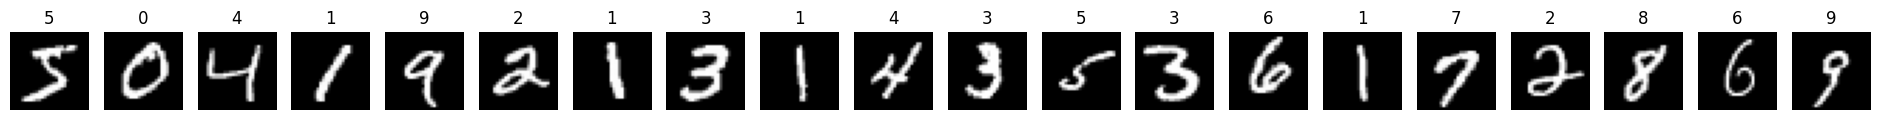

In [15]:
plot_mnist_images(mnist_train, 20)

In [16]:
print(f"Train: {len(mnist_train)}, Test: {len(mnist_test)}")

Train: 60000, Test: 10000


In [17]:
train_loader = DataLoader(
    dataset=mnist_train,
    batch_size=8,
    shuffle=True,
    generator=torch_gen,        # dedicated RNG for reproducible shuffle order
)

# val_loader = DataLoader(
#     mnist_valid,
#     batch_size=8,
#     shuffle=False,              # do not shuffle validation
# )

test_loader = DataLoader(
    dataset=mnist_test,
    batch_size=8,
    shuffle=False,              # do not shuffle test
)

In [18]:
# DataLoaders testing
images_batch, targets_batch = next(iter(train_loader))

print("Images batch shape :", images_batch.shape)
print("Targets batch shape:", targets_batch.shape)
print("Images data type   :", images_batch.dtype)
print("Targets data type  :", targets_batch.dtype)
print("Targets in batch   :", targets_batch)

Images batch shape : torch.Size([8, 1, 28, 28])
Targets batch shape: torch.Size([8])
Images data type   : torch.float32
Targets data type  : torch.int64
Targets in batch   : tensor([8, 1, 4, 6, 3, 4, 0, 2])


### Outlier detection

`IsolationForest` is best for high-dimensional, large, non-Gaussian multivariate data. We don't know how smudgy, blurred or well-written the images are. We are going to flag 1% of the easiest to isolate points, then plot them for assessment.

In [19]:
# (60000, 28, 28) -> (60000, 784)
# transformation isn't applied here, but the forest doesn't need it anyway
train_images_2d = train_images.reshape(-1, 784)

print(f"mnist_train_array_2d.shape = {train_images_2d.shape}")

mnist_train_array_2d.shape = (60000, 784)


In [20]:
# ---------- STEP 1: Fit ----------
iso = IsolationForest(
    n_estimators=500,           # number of random trees
    contamination=0.01,         # expect ~1% anomalies
    max_samples='auto',         # subsample size per tree
    random_state=RANDOM_SEED,
)

iso.fit(train_images_2d)

IsolationForest(contamination=0.01, n_estimators=500, random_state=42)

In [21]:
# ---------- STEP 2: Predict (-1 = anomaly, 1 = normal) ----------
flags = iso.predict(train_images_2d)
anomaly_mask = flags == -1
print(f"Train anomalies flagged: {anomaly_mask.sum()}")

Train anomalies flagged: 600


In [22]:
# ---------- STEP 3: Get top 5 continuous anomaly scores for ranking ----------
# Lower score = more anomalous
anomaly_score = iso.score_samples(train_images_2d)
print("Top 5 lowest (most anomalous) scores:", sorted(anomaly_score)[:5])

Top 5 lowest (most anomalous) scores: [-0.6489152565601162, -0.6395654856434693, -0.6321896152658757, -0.6289864895689281, -0.6287789506769456]


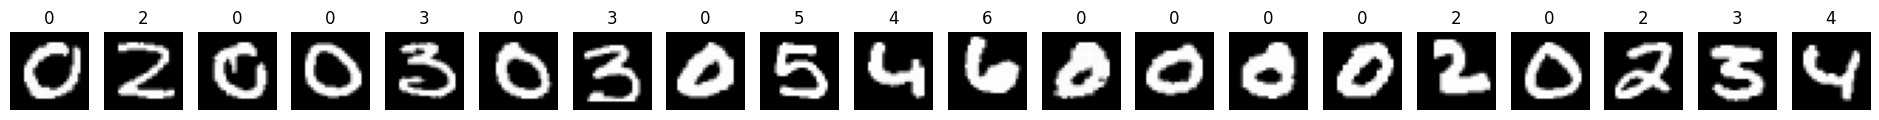

In [23]:
# ---------- STEP 4: See the flagged images ----------
outlier_idx = np.where(flags == -1)[0]
outliers_mnist_train = [mnist_train_raw[idx] for idx in outlier_idx]

plot_mnist_images(outliers_mnist_train, 20)

## Training

Selection of metrics
The same set of metrics is applied for each model.

- accuracy - basic indicator of correctly identified percentages
- f1-score - balance between precision and recall, but it will unlikely matter in a balanced dataset (checked and confirmed; it is roughly accuracy across trainings)
- loss - minimized measure of cross-entropy; standard multi-classification softmax

Interface. Each model class will inherit these.

In [24]:
from abc import ABC, abstractmethod


class MnistClassifierInterface(ABC):
    """Interface that represents each classifier."""

    @abstractmethod
    def train(self) -> dict:
        """Trains the model, returns logs with metrics / losses on train / validation."""

    @abstractmethod
    def predict(self, X: np.ndarray, y_true: np.ndarray = None) -> np.ndarray:
        """Predicts X with the trained model, returns predictions."""

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate


class LogisticRegressionModel(MnistClassifierInterface):
    """Logistic Regression classifier class."""

    def __init__(self, train_dataset, max_iter: int = 100, batch_size=125, random_state=42, n_jobs: int | None = None, verbose: int = 0):
        if n_jobs is None:
            n_jobs = os.cpu_count() or 1 # Fallback to 1 if cpu_count() returns None

        self.model = LogisticRegression(max_iter=max_iter,
                                        random_state=random_state,
                                        n_jobs=n_jobs,
                                        verbose=verbose)
        self.train_dataset = train_dataset
        self.batch_size = batch_size
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.verbose = verbose

    def train(self):
        """Trains Logistic Regression on the full training dataset."""
        # --- Define Data Loaders ---
        train_loader = DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=False,                   # no need to shuffle, sklearn doesn't care and split had shuffled the train
            num_workers=2,
            drop_last=False,                 # no need to discard uneven batches, there's no BatchNorm here
        )

        # 2. --- Extract Train Data (flatten into 2D train data for sklearn) ---
        X_train, y_train = [], []
        print("Extracting training data...")
        for images, labels in train_loader:
            X_train.extend(images.numpy().reshape(images.shape[0], -1)) # (batch_size, 1, 28, 28) -> (batch_size, 1*28*28)
            y_train.extend(labels.numpy())
        X_train = np.array(X_train)
        y_train = np.array(y_train)

        # 3. --- CROSS-VALIDATION ---
        print("\n--- Running 5-Fold Cross-Validation ---")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)

        cv_results = cross_validate(
            self.model, X_train, y_train,
            cv=cv,
            scoring=["accuracy", "f1_macro"],
            return_train_score=True,
            n_jobs=self.n_jobs,
            verbose=self.verbose,
        )

        if self.verbose:
            print(f"CV Train Accuracy: {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")
            print(f"CV Train F1-Macro: {cv_results['train_f1_macro'].mean():.4f} ± {cv_results['train_f1_macro'].std():.4f}")
            print(f"CV Val Accuracy:   {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
            print(f"CV Val F1-Macro:   {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}\n")

        # 4. --- Final Fit ---
        print("--- Fitting Final Model on Full Train Set ---")
        self.model.fit(X_train, y_train)

        logs = {
            "cv_train_accuracy_mean": cv_results['train_accuracy'].mean(),
            "cv_train_f1_mean": cv_results['train_f1_macro'].mean(),
            "cv_test": cv_results['test_accuracy'].mean(),
            "cv_test_f1_mean": cv_results['test_f1_macro'].mean(),
        }

        return logs

    def predict(self, dataset) -> np.ndarray:
        """Predict labels for MNIST images."""
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        X, y = [], []
        for images, labels in loader:
            X.extend(images.numpy().reshape(images.shape[0], -1))
            y.extend(labels.numpy())
        X = np.array(X)
        y = np.array(y)

        preds = self.model.predict(X)
        return preds, y

In [ ]:
from torch.utils.data import Subset
from sklearn.metrics import accuracy_score, f1_score
import torch.optim as optim
from tqdm import tqdm

class FeedForwardClassifierModel(MnistClassifierInterface):
    """Feed Forward Neural Network classifier class."""

    def __init__(self, train_dataset, batch_size: int, epochs: int, criterion: nn.Module = nn.CrossEntropyLoss,
                 optimizer: optim.Optimizer = optim.Adam, optim_kwargs=None,
                 random_state=42, verbose: int = 0, device: str | None = None):

        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Device - {self.device}")

        # storing the architecture, not a single model - CV needs a fresh one per fold
        self._build_model = lambda: nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

        self.model = self._build_model().to(self.device)
        print("Number of trainable parameters -", sum(p.numel() for p in self.model.parameters() if p.requires_grad))

        self.train_dataset = train_dataset
        self.batch_size = batch_size
        self.epochs = epochs
        self.optimizer = optimizer
        self.optim_kwargs = optim_kwargs or {"lr": 1e-3}
        self.criterion = criterion
        self.random_state = random_state
        self.verbose = verbose

    def _evaluate_loader(self, model, loader):
        """Helper to compute accuracy, macro-f1 and loss for a given batch (given via loader) and a given model."""
        model.eval()
        all_preds, all_labels = [], []
        running_loss = 0.0

        with torch.no_grad():
            for X, y in loader:
                X, y = X.to(self.device), y.to(self.device)
                logits = model(X)
                loss = self.criterion(logits, y)
                running_loss += loss.item()         # extract a scalar itself from a huge object keeping track of all gradient operations
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy()) # return the first index of the highest value
                all_labels.extend(y.cpu().numpy())

        return (accuracy_score(all_labels, all_preds),
                f1_score(all_labels, all_preds, average="macro"),
                running_loss / len(loader))

    def _train_epochs(self, model, train_loader, val_loader, desc):
        """Runs self.epochs. Returns per-epoch (train_loss, train_acc, val_loss, val_acc) lists."""
        optimizer = self.optimizer(model.parameters(), **self.optim_kwargs)
        tr_losses, tr_accs, va_losses, va_accs = [], [], [], []

        progress = tqdm(range(self.epochs), desc=desc, disable=not self.verbose, ncols=110)
        for _ in progress:
            model.train()
            running_loss, correct, total = 0.0, 0, 0

            for X, y in train_loader:
                X, y = X.to(self.device), y.to(self.device)

                optimizer.zero_grad()
                y_hat = model(X)
                loss = self.criterion(y_hat, y)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                correct += (y_hat.argmax(dim=1) == y).sum().item()   # train acc, free from y_hat
                total += y.size(0)

            tr_losses.append(running_loss / len(train_loader))
            tr_accs.append(correct / total)

            if val_loader is not None:
                va_acc, _, va_loss = self._evaluate_loader(model, val_loader)
                va_losses.append(va_loss)
                va_accs.append(va_acc)
                progress.set_postfix({"train_loss": f"{tr_losses[-1]:.4f}", "val_loss": f"{va_loss:.4f}"})
            else:
                progress.set_postfix({"train_loss": f"{tr_losses[-1]:.4f}"})

        return tr_losses, tr_accs, va_losses, va_accs

    def train(self) -> dict:
        """Trains the FFNN using Cross-Validation, then fits on the full dataset."""

        # 1. --- Extract targets for StratifiedKFold ---
        if self.verbose:
            print("Extracting labels for Stratified Split...")
        y_all = [self.train_dataset[i][1] for i in range(len(self.train_dataset))]
        X_dummy = np.zeros(len(y_all))   # sklearn only needs the sample count

        # 2. --- CROSS-VALIDATION ---
        if self.verbose:
            print(f"\n--- Running 5-Fold Cross-Validation on {self.device} ---")
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)

        all_tr_losses, all_tr_accs, all_va_losses, all_va_accs, cv_val_f1 = [], [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X_dummy, y_all)):
            fold_train_loader = DataLoader(Subset(self.train_dataset, train_idx),
                                           batch_size=self.batch_size, shuffle=True)
            fold_val_loader = DataLoader(Subset(self.train_dataset, val_idx),
                                         batch_size=self.batch_size, shuffle=False)

            fold_model = self._build_model().to(self.device)   # FRESH weights per fold
            tr_l, tr_a, va_l, va_a = self._train_epochs(
                fold_model, fold_train_loader, fold_val_loader, f"Fold {fold + 1}/5")

            all_tr_losses.append(tr_l); all_tr_accs.append(tr_a)
            all_va_losses.append(va_l); all_va_accs.append(va_a)

            _, val_f1, _ = self._evaluate_loader(fold_model, fold_val_loader)
            cv_val_f1.append(val_f1)

        # 3. --- Final Fit on Full Dataset ---
        if self.verbose:
            print("\n--- Fitting Final Model on Full Train Set ---")
        full_train_loader = DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)
        self.model = self._build_model().to(self.device)
        self._train_epochs(self.model, full_train_loader, None, "Final fit")

        # curves averaged across the 5 folds -> one value per epoch
        return {
            "train_losses":     np.mean(all_tr_losses, axis=0),
            "valid_losses":     np.mean(all_va_losses, axis=0),
            "train_accuracies": np.mean(all_tr_accs, axis=0),
            "valid_accuracies": np.mean(all_va_accs, axis=0),
            "cv_val_accuracy_mean": np.mean([a[-1] for a in all_va_accs]),
            "cv_val_f1_mean":       np.mean(cv_val_f1),
        }

    def predict(self, dataset) -> np.ndarray:
        """Predict labels for MNIST images."""
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)
        self.model.eval()

        all_preds, all_labels = [], []
        with torch.no_grad():
            for X, y in loader:
                logits = self.model(X.to(self.device))
                all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                all_labels.extend(y.numpy())

        return np.array(all_preds), np.array(all_labels)

In [ ]:
class MnistClassifier:
    """
    Wrapper class that utilizes specific algorithms under the hood.

    Allows using 'rf', 'nn', or 'cnn' with same train/predict API.
    """

    def __init__(self, algorithm: str, **kwargs):
        # --- init the proper model + sanity check ---
        if algorithm == "logistic_regression":
            self.model = LogisticRegressionModel(**kwargs)
        elif algorithm == "fnn":
            self.model = FeedForwardClassifierModel(**kwargs)
        else:
            msg = f"Unknown algorithm: {algorithm}"
            raise ValueError(msg)

    def train(self):
        logs = self.model.train()
        return logs

    def predict(self, dataset):
        return self.model.predict(dataset)

In [ ]:
log_reg_model = MnistClassifier(
    algorithm="logistic_regression",
    train_dataset=mnist_train,
    # val_dataset=mnist_valid,
    batch_size=125,
    random_state=RANDOM_SEED,
    verbose=1,
    n_jobs=os.cpu_count(),
)

torch.manual_seed(RANDOM_SEED)

logs = log_reg_model.train()

Extracting training data...


For gradient-based shallow network (standard FFN or MLP), we choose:

- Input layer: 784 neurons (28x28 - 784 pixels)
- Hidden layer: 128 neurons (arbitrary, assuming it is a simple task)
- Output layer: 128 neurons enter (matches the hidden) and 10 out (10 classes to predict)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

fnn_model = MnistClassifier(
    algorithm="fnn",
    train_dataset=mnist_train,
    batch_size=125,
    epochs=20,
    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam, optim_kwargs={"lr":1e-3},
    random_state=RANDOM_SEED,
    n_jobs=os.cpu_count(),
    verbose=1,
    device=device,
)

torch.manual_seed(RANDOM_SEED)
logs = fnn_model.train()